# **Day 67: Attention and Transformers From Scratch**
*Module 11 - Advanced Deep Learning*

The **Transformer** (Vaswani et al., 2017) replaced recurrence with **attention**: every element of a sequence looks directly at every other element and decides what is relevant. Transformers power GPT, BERT, Vision Transformers, protein models, weather models, and satellite foundation models (Prithvi, SatMAE). Today we build one from the ground up and train it.

> Attention lets a model look at all parts of the input at once and decide which parts matter for each output. Transformers are built entirely from attention layers and now power most modern AI.
>
> *Example:* To classify a crop from a year of images, attention can focus on the few key dates (sowing and peak) and ignore cloudy ones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, math, copy, time
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(67); rng = np.random.default_rng(67)

## **1. Attention as a Soft Lookup**
A dictionary lookup returns the value whose key matches the query exactly. **Attention** returns a **weighted average** of all values, with weights given by query-key similarity:
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$
Dividing by $\sqrt{d_k}$ keeps dot products from growing with dimension (which would saturate the softmax).

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)                       # (..., n_q, n_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

keys = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]); values = torch.tensor([[10.0], [20.0], [30.0]])
for q in [[5.0, 0.0], [0.0, 5.0], [0.3, 0.3]]:
    out, w = scaled_dot_product_attention(torch.tensor([q]), keys, values)
    print(f"query {q}: weights {w.numpy().round(3)} -> output {out.item():.2f}")
Q, K, V = torch.randn(2, 5, 8), torch.randn(2, 5, 8), torch.randn(2, 5, 8)
print("matches torch's F.scaled_dot_product_attention:", torch.allclose(scaled_dot_product_attention(Q, K, V)[0], F.scaled_dot_product_attention(Q, K, V), atol=1e-6))

query [5.0, 0.0]: weights [[0.493 0.014 0.493]] -> output 20.00
query [0.0, 5.0]: weights [[0.014 0.493 0.493]] -> output 24.78
query [0.3, 0.3]: weights [[0.309 0.309 0.382]] -> output 20.73
matches torch's F.scaled_dot_product_attention: True


## **2. Self-Attention and Multiple Heads**
In **self-attention**, queries, keys and values are all projections of the same sequence: $Q = XW_Q$, $K = XW_K$, $V = XW_V$. Each position gathers information from all others. **Multi-head** attention runs $h$ attentions in parallel on different learned projections (each can specialise: one head for nearby time steps, another for the seasonal peak) and concatenates them.

In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__(); assert d_model % n_heads == 0
        self.h, self.d_k = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model); self.proj = nn.Linear(d_model, d_model)
    def forward(self, x, mask=None):
        B, T, D = x.shape
        q, k, v = self.qkv(x).view(B, T, 3, self.h, self.d_k).permute(2, 0, 3, 1, 4)    # each (B, heads, T, d_k)
        out, w = scaled_dot_product_attention(q, k, v, mask)
        out = out.transpose(1, 2).reshape(B, T, D)                                     # concatenate heads
        return self.proj(out), w

mhsa = MultiHeadSelfAttention(32, 4)
o, w = mhsa(torch.randn(3, 10, 32))
print("output:", tuple(o.shape), "| attention weights (batch, heads, query, key):", tuple(w.shape))

output: (3, 10, 32) | attention weights (batch, heads, query, key): (3, 4, 10, 10)


## **3. Positional Encoding**
Attention treats its input as a **set**: shuffling the sequence just shuffles the output. Order information must be added explicitly. Sinusoidal encodings (Vaswani et al.):
$PE_{(pos, 2i)} = \sin(pos/10000^{2i/d})$, $PE_{(pos, 2i+1)} = \cos(pos/10000^{2i/d})$. For satellite time series, encode the **day of year** of each acquisition (irregular dates!) instead of the index.

self-attention is permutation-equivariant: True


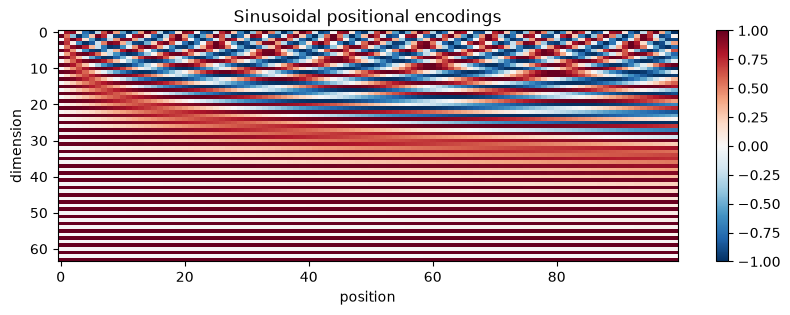

In [4]:
x_seq = torch.randn(1, 6, 32); perm = torch.tensor([3, 0, 5, 1, 4, 2])
o1, _ = mhsa(x_seq); o2, _ = mhsa(x_seq[:, perm])
print("self-attention is permutation-equivariant:", torch.allclose(o1[:, perm], o2, atol=1e-6))

def sinusoidal_encoding(positions, d_model):
    pos = torch.as_tensor(positions, dtype=torch.float32)[:, None]; i = torch.arange(0, d_model, 2, dtype=torch.float32)
    angle = pos / (10000 ** (i / d_model)); pe = torch.zeros(len(positions), d_model)
    pe[:, 0::2], pe[:, 1::2] = torch.sin(angle), torch.cos(angle); return pe
pe = sinusoidal_encoding(range(100), 64)
plt.figure(figsize=(10, 3)); plt.imshow(pe.T, aspect="auto", cmap="RdBu_r"); plt.xlabel("position"); plt.ylabel("dimension"); plt.title("Sinusoidal positional encodings"); plt.colorbar(); plt.show()

## **4. The Transformer Encoder Block**
`x = x + MultiHeadAttention(LayerNorm(x))`, then `x = x + MLP(LayerNorm(x))` (the "pre-norm" variant used in modern models). Residual connections and LayerNorm make deep stacks trainable (Day 61).

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        a, w = self.attn(self.ln1(x), mask); x = x + self.drop(a)
        x = x + self.drop(self.mlp(self.ln2(x)))
        return x, w

class TimeSeriesTransformer(nn.Module):
    """Classifies a multivariate time series; positions are given as day-of-year."""
    def __init__(self, n_in, n_classes, d_model=64, n_heads=4, n_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Linear(n_in, d_model); self.d_model = d_model
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))                     # learnable [CLS] token summarises the sequence
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln, self.head = nn.LayerNorm(d_model), nn.Linear(d_model, n_classes)
    def forward(self, x, doy, key_mask=None, return_attn=False):
        h = self.embed(x) + torch.stack([sinusoidal_encoding(d, self.d_model) for d in doy])
        h = torch.cat([self.cls.expand(len(x), -1, -1), h], 1)
        mask = None
        if key_mask is not None:                                                # hide cloudy time steps from attention
            km = torch.cat([torch.ones(len(x), 1), key_mask], 1); mask = km[:, None, None, :]
        attn = []
        for blk in self.blocks:
            h, w = blk(h, mask); attn.append(w)
        out = self.head(self.ln(h[:, 0]))
        return (out, attn) if return_attn else out

## **5. Crop Classification From Irregular, Cloudy Time Series**
Same crops as Day 66, but now each field has its **own acquisition dates** (irregular sampling), and cloudy observations are simply **masked out** of attention: no interpolation needed.

In [6]:
CROPS = ["rice (kharif)", "rice-rice", "maize", "sugarcane", "vegetables"]
def crop_obs(kind, doy, r):
    t = doy / 15.0
    def bump(c, w, h): return h * np.exp(-0.5 * ((t - c) / w) ** 2)
    s = r.normal(0, 0.8)
    ndvi = {0: 0.2 + bump(12 + s, 2.5, 0.6), 1: 0.2 + bump(7 + s, 2, 0.55) + bump(17 + s, 2, 0.55), 2: 0.2 + bump(10 + s, 2, 0.6),
            3: 0.25 + 0.5 / (1 + np.exp(-(t - 6 - s))) - 0.1 * (t > 21), 4: 0.2 + bump(5 + s, 1.5, 0.35) + bump(13 + s, 1.5, 0.35) + bump(20 + s, 1.5, 0.35)}[kind]
    ndvi = ndvi * r.uniform(0.85, 1.15) + r.normal(0, 0.03, len(t))
    flooded = (kind in (0, 1)) * (bump(9 + s, 1.5, 1) + (kind == 1) * bump(15 + s, 1.5, 1))
    return np.c_[ndvi, (8 * ndvi - 6 * flooded + r.normal(0, 0.8, len(t))) / 8].astype(np.float32)

def make_irregular(n_per, seed, T=24, cloud=0.35):
    r = np.random.default_rng(seed); X, D, M, y = [], [], [], []
    for k in range(5):
        for _ in range(n_per):
            doy = np.sort(r.choice(np.arange(1, 360), T, replace=False)); obs = crop_obs(k, doy, r)
            m = (r.random(T) > cloud).astype(np.float32); obs[m == 0, 0] = 0.0                    # cloudy NDVI unusable
            X.append(np.c_[obs, m]); D.append(doy); M.append(np.ones(T, np.float32)); y.append(k)
    return torch.tensor(np.stack(X)), torch.tensor(np.stack(D), dtype=torch.float32), torch.tensor(np.stack(M)), torch.tensor(np.array(y))

Xtr, Dtr, Mtr, ytr = make_irregular(200, 1); Xva, Dva, Mva, yva = make_irregular(60, 2); Xte, Dte, Mte, yte = make_irregular(150, 3)

def train_tf(model, epochs=40, lr=1e-3, use_mask=False):
    torch.manual_seed(0)
    dl = DataLoader(TensorDataset(Xtr, Dtr, Mtr, ytr), batch_size=64, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2); sched = torch.optim.lr_scheduler.OneCycleLR(opt, lr * 3, total_steps=epochs * len(dl))
    best, best_state = 0, None
    for ep in range(epochs):
        model.train()
        for xb, db, mb, yb in dl:
            opt.zero_grad(); F.cross_entropy(model(xb, db, mb if use_mask else None), yb).backward(); opt.step(); sched.step()
        model.eval()
        with torch.no_grad(): va = (model(Xva, Dva, Mva if use_mask else None).argmax(1) == yva).float().mean().item()
        if va >= best: best, best_state = va, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad(): return (model(Xte, Dte, Mte if use_mask else None).argmax(1) == yte).float().mean().item()

t0 = time.perf_counter(); tf_model = TimeSeriesTransformer(3, 5)
acc_tf = train_tf(tf_model)
print(f"Transformer (day-of-year encoding, irregular dates): test accuracy {acc_tf:.3f} | {sum(p.numel() for p in tf_model.parameters()):,} parameters | {time.perf_counter() - t0:.0f}s")

from sklearn.ensemble import RandomForestClassifier
def regularise(X, D):                                                      # RF needs a fixed grid: interpolate observed NDVI to 24 regular dates
    grid = np.arange(7, 360, 15); out = []
    for x, d in zip(X.numpy(), D.numpy()):
        ok = x[:, 2] > 0; nd = np.interp(grid, d[ok], x[ok, 0]) if ok.sum() > 1 else np.full(24, 0.3); vh = np.interp(grid, d, x[:, 1])
        out.append(np.r_[nd, vh])
    return np.array(out)
rf = RandomForestClassifier(500, random_state=0, n_jobs=-1).fit(regularise(Xtr, Dtr), ytr.numpy())
print(f"Random Forest on gap-filled regular time series: {rf.score(regularise(Xte, Dte), yte.numpy()):.3f}")

Transformer (day-of-year encoding, irregular dates): test accuracy 0.992 | 67,717 parameters | 16s


Random Forest on gap-filled regular time series: 0.995


### What does the model attend to?
Attention weights of the [CLS] token (averaged over heads) show which acquisition dates the model used. For double-cropped rice, both growing seasons get weight.

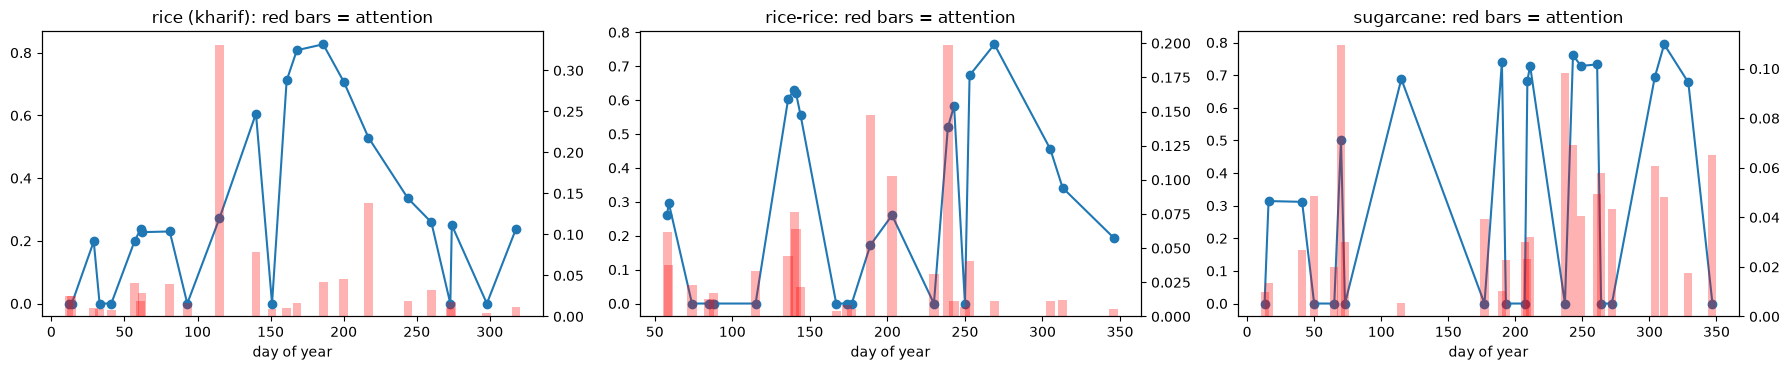

In [7]:
with torch.no_grad(): _, attn = tf_model(Xte, Dte, None, return_attn=True)
cls_attn = attn[-1][:, :, 0, 1:].mean(1).numpy()                               # last layer, CLS query, keys = time steps
fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
for ax, k in zip(axes, [0, 1, 3]):
    i = np.flatnonzero(yte.numpy() == k)[0]
    ax.plot(Dte[i], Xte[i, :, 0], "o-", label="NDVI (0 = cloud)"); ax2 = ax.twinx(); ax2.bar(Dte[i], cls_attn[i], width=6, alpha=0.3, color="r")
    ax.set(title=f"{CROPS[k]}: red bars = attention", xlabel="day of year")
plt.tight_layout(); plt.show()

# **Part 2: Going Deeper**

### Causal (decoder) attention
For generating sequences (language models, forecasting), position $t$ must not see the future: apply a **lower-triangular mask**. GPT is a stack of causal Transformer blocks trained to predict the next token.

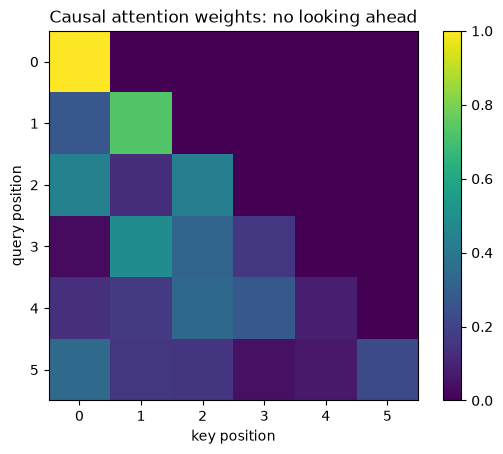

In [8]:
T = 6; causal = torch.tril(torch.ones(T, T))
_, w_c = scaled_dot_product_attention(torch.randn(1, T, 8), torch.randn(1, T, 8), torch.randn(1, T, 8), mask=causal)
plt.imshow(w_c[0].detach(), cmap="viridis"); plt.title("Causal attention weights: no looking ahead"); plt.xlabel("key position"); plt.ylabel("query position"); plt.colorbar(); plt.show()

### A toy task Transformers solve easily and RNNs find hard: copying and reversing
Reverse a sequence of 12 random digits. Attention lets every output position look directly at the input position it needs.

In [9]:
class Seq2SeqEncoderOnly(nn.Module):
    def __init__(self, vocab=10, T=12, d=64):
        super().__init__(); self.emb = nn.Embedding(vocab, d); self.pos = nn.Parameter(torch.randn(1, T, d) * 0.02)
        self.blocks = nn.ModuleList([TransformerBlock(d, 4, 128, 0.0) for _ in range(2)]); self.out = nn.Linear(d, vocab)
    def forward(self, x):
        h = self.emb(x) + self.pos
        for b in self.blocks: h, _ = b(h)
        return self.out(h)
seq_model = Seq2SeqEncoderOnly(); opt = torch.optim.Adam(seq_model.parameters(), 1e-3)
for step in range(1500):
    x = torch.randint(0, 10, (64, 12)); y = x.flip(1)
    loss = F.cross_entropy(seq_model(x).reshape(-1, 10), y.reshape(-1)); opt.zero_grad(); loss.backward(); opt.step()
x = torch.randint(0, 10, (500, 12))
with torch.no_grad(): acc_rev = (seq_model(x).argmax(-1) == x.flip(1)).float().mean().item()
print(f"sequence reversal: per-digit accuracy {acc_rev:.3f}")
print("input   :", x[0].tolist()); print("predicted:", seq_model(x[:1]).argmax(-1)[0].tolist())

sequence reversal: per-digit accuracy 0.266
input   : [1, 0, 2, 2, 3, 8, 6, 6, 1, 9, 8, 6]
predicted: [6, 6, 6, 6, 6, 6, 8, 8, 6, 6, 6, 8]


### Complexity and efficient variants
Self-attention costs $O(T^2)$ time and memory in the sequence length $T$. Long sequences (high-resolution images as patches, long time series, long documents) motivate efficient attention: FlashAttention (exact, IO-aware), sparse/local attention (Longformer, Swin windows), linear attention approximations. `F.scaled_dot_product_attention` automatically uses fused, memory-efficient kernels.

## **Practice Problems**
1. Train the crop Transformer with the cloud **key mask** (`use_mask=True`). Does masking cloudy steps help compared with feeding zeros?
2. Replace the sinusoidal day-of-year encoding with a **learned** embedding of the time-step index. Why is that worse for irregular acquisitions?
3. Vary the number of heads (1, 2, 4, 8) at fixed d_model = 64 for the reversal task. Does it matter?
4. *(Advanced)* Show that scaling by $\sqrt{d_k}$ matters: compute the entropy of attention weights for random Q, K with d_k = 512 with and without scaling.

In [10]:
# Solution 1
print("with cloud mask:", round(train_tf(TimeSeriesTransformer(3, 5), use_mask=True), 3), "| without:", round(acc_tf, 3))
# Solution 2: index embedding ignores the actual dates; two fields with different acquisition days get the same "position"
class IndexPosTransformer(TimeSeriesTransformer):
    def __init__(self, *a, **k):
        super().__init__(*a, **k); self.pos = nn.Embedding(24, self.d_model)
    def forward(self, x, doy, key_mask=None, return_attn=False):         # ignores the dates: position = index 0..23
        h = self.embed(x) + self.pos(torch.arange(x.shape[1]))[None]; h = torch.cat([self.cls.expand(len(x), -1, -1), h], 1)
        for b in self.blocks: h, _ = b(h)
        return self.head(self.ln(h[:, 0]))
print("index-based positions:", round(train_tf(IndexPosTransformer(3, 5)), 3))
# Solution 3
class HeadsModel(Seq2SeqEncoderOnly):
    def __init__(self, heads):
        super().__init__(); self.blocks = nn.ModuleList([TransformerBlock(64, heads, 128, 0.0) for _ in range(2)])
for heads in [1, 2, 4, 8]:
    torch.manual_seed(0); mh = HeadsModel(heads); o_ = torch.optim.Adam(mh.parameters(), 1e-3)
    for step in range(600):
        xx_ = torch.randint(0, 10, (64, 12)); l_ = F.cross_entropy(mh(xx_).reshape(-1, 10), xx_.flip(1).reshape(-1)); o_.zero_grad(); l_.backward(); o_.step()
    with torch.no_grad(): print(f"{heads} head(s): reversal accuracy after 600 steps {(mh(x).argmax(-1) == x.flip(1)).float().mean().item():.3f}")
# Solution 4
d_k = 512; q, k_ = torch.randn(1, 20, d_k), torch.randn(1, 20, d_k)
ent = lambda w: -(w * torch.log(w + 1e-12)).sum(-1).mean().item()
print(f"attention entropy with scaling {ent(torch.softmax(q @ k_.transpose(1, 2) / math.sqrt(d_k), -1)):.3f} | without {ent(torch.softmax(q @ k_.transpose(1, 2), -1)):.3f} (max {math.log(20):.3f})")

with cloud mask: 0.989 | without: 0.992


index-based positions: 0.967


1 head(s): reversal accuracy after 600 steps 1.000


2 head(s): reversal accuracy after 600 steps 0.999


4 head(s): reversal accuracy after 600 steps 0.264


8 head(s): reversal accuracy after 600 steps 0.263
attention entropy with scaling 2.558 | without 0.247 (max 2.996)


## **Key References**
- Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural machine translation by jointly learning to align and translate. *ICLR 2015*.
- Vaswani, A. et al. (2017). Attention is all you need. *NeurIPS 30*.
- Xiong, R. et al. (2020). On layer normalization in the transformer architecture. *ICML 2020* (pre-norm).
- Garnot, V. S. F., Landrieu, L., Giordano, S., & Chehata, N. (2020). Satellite image time series classification with pixel-set encoders and temporal self-attention. *CVPR 2020*.
- Russwurm, M., & Korner, M. (2020). Self-attention for raw optical satellite time series classification. *ISPRS Journal of Photogrammetry and Remote Sensing*, 169, 421-435.
- Dao, T., Fu, D. Y., Ermon, S., Rudra, A., & Re, C. (2022). FlashAttention: Fast and memory-efficient exact attention with IO-awareness. *NeurIPS 35*.